# Reinforcement Learning: Returns, Bellman Equations, and the Score Trick

This notebook uses the same small gridworld log as the lecture. It computes
returns and evaluates a policy directly with NumPy before checking the same
fixed point with linear algebra, and then differentiates a bandit objective
whose sampling distribution depends on the parameters. The question to keep in
view is: **which quantities can be estimated from played actions alone?**

In [1]:
# Colab opens this notebook on its own, so fetch the data files that sit
# beside it in the course repository. Running locally, this does nothing.
from pathlib import Path as _Path
import urllib.request as _req
_RAW = 'https://raw.githubusercontent.com/ZhuoranYang/sds265-fall26/main/demos/20-reinforcement-learning/'
for _name in ['gridworld-logged-trajectories.csv']:
    if not _Path(_name).exists():
        _req.urlretrieve(_RAW + _name, _name)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 26523
rng = np.random.default_rng(SEED)
transitions = pd.read_csv('gridworld-logged-trajectories.csv')
transitions

,episode,t,state,action,reward,next_state,done
0,0,0,"(2,0)",right,0,"(2,1)",False
1,0,1,"(2,1)",up,0,"(1,1)",False
2,0,2,"(1,1)",right,0,"(1,2)",False
3,0,3,"(1,2)",up,0,"(0,2)",False
4,0,4,"(0,2)",right,1,"(0,3)",True
5,1,0,"(2,0)",up,0,"(1,0)",False
6,1,1,"(1,0)",right,0,"(1,1)",False
7,1,2,"(1,1)",up,0,"(0,1)",False
8,1,3,"(0,1)",right,0,"(0,2)",False
9,1,4,"(0,2)",right,1,"(0,3)",True


## 1. Discounted returns in the recorded data

The return is computed backward. This makes the recursion
$G_t=r_t+\gamma G_{t+1}$ explicit rather than hiding it in a library call.
Notice that every reward in this episode is zero until the last step, yet the
early rows still carry a positive return: that is delayed credit, made
visible.

In [2]:
def discounted_returns(rewards, gamma=0.9):
    result = np.zeros(len(rewards), dtype=float)
    running = 0.0
    for index in range(len(rewards) - 1, -1, -1):
        running = rewards[index] + gamma * running
        result[index] = running
    return result

episode0 = transitions.query("episode == 0").copy()
episode0["return"] = discounted_returns(episode0["reward"].to_numpy(), gamma=0.9)
episode0[["t", "state", "action", "reward", "next_state", "return"]]

,t,state,action,reward,next_state,return
0,0,"(2,0)",right,0,"(2,1)",0.6561
1,1,"(2,1)",up,0,"(1,1)",0.7290
2,2,"(1,1)",right,0,"(1,2)",0.8100
3,3,"(1,2)",up,0,"(0,2)",0.9000
4,4,"(0,2)",right,1,"(0,3)",1.0000


## 2. Policy evaluation from scratch

We use a three-state MDP with a fixed policy already averaged in, so the
Bellman equation is the linear system $V^\pi=r^\pi+\gamma P^\pi V^\pi$. The
next cell first iterates the backup; only afterwards do we verify the same
fixed point with `numpy.linalg.solve`.

In [3]:
gamma = 0.9
# Rows are current states and columns are next states after averaging over a fixed policy.
P_pi = np.array([[0.5, 0.5, 0.0],
                 [0.0, 0.4, 0.6],
                 [0.0, 0.0, 1.0]])
r_pi = np.array([0.0, 0.6, 0.0])

def evaluate_policy_iteratively(P, r, gamma, tolerance=1e-12):
    value = np.zeros_like(r, dtype=float)
    history = [value.copy()]
    while True:
        updated = r + gamma * P @ value
        history.append(updated.copy())
        if np.max(np.abs(updated - value)) < tolerance:
            return updated, np.array(history)
        value = updated

value_iterative, history = evaluate_policy_iteratively(P_pi, r_pi, gamma)
value_exact = np.linalg.solve(np.eye(3) - gamma * P_pi, r_pi)
pd.DataFrame({"iterative": value_iterative, "linear_system": value_exact,
              "absolute_difference": np.abs(value_iterative - value_exact)})

,iterative,linear_system,absolute_difference
0,0.767045,0.767045,8.043566e-13
1,0.937500,0.937500,1.110223e-16
2,0.000000,0.000000,0.000000e+00


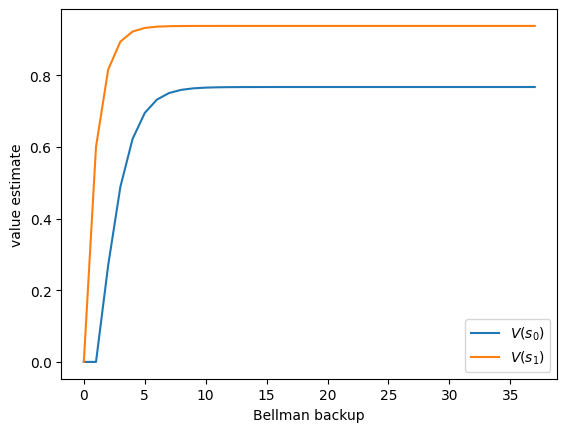

In [4]:
plt.plot(history[:, 0], label="$V(s_0)$")
plt.plot(history[:, 1], label="$V(s_1)$")
plt.xlabel("Bellman backup")
plt.ylabel("value estimate")
plt.legend();

## 3. Values, action values, and advantages

Now keep the actions separate. With $P[s,a,s']$ and $r[s,a]$ we can build
$P^\pi$ and $r^\pi$ for any policy, solve for $V^\pi$, and read off

$$Q^\pi(s,a)=r(s,a)+\gamma\sum_{s'}P(s'\mid s,a)V^\pi(s'),\qquad
A^\pi(s,a)=Q^\pi(s,a)-V^\pi(s).$$

The claim to check numerically is that $\sum_a\pi(a\mid s)A^\pi(s,a)=0$ at every
state.

In [5]:
P = np.array([
    [[0.10, 0.80, 0.10], [0.70, 0.20, 0.10]],   # s0: actions 0 and 1
    [[0.05, 0.20, 0.75], [0.60, 0.35, 0.05]],   # s1
    [[0.40, 0.10, 0.50], [0.10, 0.10, 0.80]],   # s2
])
R = np.array([[0.0, 0.4], [0.3, 0.1], [1.0, 0.2]])
MU = np.array([1.0, 0.0, 0.0])
GAMMA = 0.9

def softmax_rows(theta):
    shifted = theta - theta.max(axis=1, keepdims=True)
    weights = np.exp(shifted)
    return weights / weights.sum(axis=1, keepdims=True)

def evaluate(pi):
    P_pi = np.einsum("sa,sat->st", pi, P)
    r_pi = np.einsum("sa,sa->s", pi, R)
    V = np.linalg.solve(np.eye(3) - GAMMA * P_pi, r_pi)
    Q = R + GAMMA * np.einsum("sat,t->sa", P, V)
    A = Q - V[:, None]
    return V, Q, A, float(MU @ V)

theta = np.array([[0.3, -0.2], [0.0, 0.4], [-0.1, 0.2]])
pi = softmax_rows(theta)
V, Q, A, J = evaluate(pi)
print("J(pi) =", round(J, 4))
pd.DataFrame({"pi(a=0|s)": pi[:, 0], "V": V, "Q(s,0)": Q[:, 0], "Q(s,1)": Q[:, 1],
              "A(s,0)": A[:, 0], "A(s,1)": A[:, 1],
              "sum_a pi*A": (pi * A).sum(axis=1)}, index=["s0", "s1", "s2"])

J(pi) = 2.8291


,pi(a=0|s),V,"Q(s,0)","Q(s,1)","A(s,0)","A(s,1)",sum_a pi*A
s0,0.622459,2.829140,2.705935,3.032271,-0.123205,0.203131,-3.469447e-16
s1,0.401312,2.965553,3.331963,2.719942,0.366410,-0.245612,1.387779e-16
s2,0.425557,3.512373,3.865958,3.250431,0.353585,-0.261942,0.000000e+00


## 4. The bandit: differentiating an expectation you sample from

Set the horizon to one. With $J(\theta)=\sum_a\pi_\theta(a)r(a)$ we can compute
the gradient exactly, because the sum is finite and we wrote down $r$. A
learner cannot: it sees $r$ only at the action it played. The score trick
rewrites the same gradient as an expectation under $\pi_\theta$,

$$\nabla_\theta J(\theta)=\mathbb E_{a\sim\pi_\theta}
  \big[\nabla_\theta\log\pi_\theta(a)\,\{r(a)-b\}\big],$$

so we can compare the exact value against the sampled estimator.

In [6]:
arm_rewards = np.array([0.9, 1.0, 0.8])

def softmax(vector):
    weights = np.exp(vector - vector.max())
    return weights / weights.sum()

def exact_gradient(theta):
    # d/dtheta_j of sum_a pi(a) r(a) for a softmax policy.
    pi = softmax(theta)
    return pi * (arm_rewards - pi @ arm_rewards)

def sampled_gradient(theta, draws, baseline=None, generator=None):
    generator = generator or np.random.default_rng(SEED)
    pi = softmax(theta)
    actions = generator.choice(len(pi), size=draws, p=pi)
    weights = arm_rewards[actions]
    if baseline is not None:
        weights = weights - baseline
    scores = np.eye(len(pi))[actions] - pi          # e_a - pi
    return (scores * weights[:, None]), pi

theta0 = np.array([0.0, 0.0, 0.0])
samples_no_baseline, pi0 = sampled_gradient(theta0, 200_000)
samples_baseline, _ = sampled_gradient(theta0, 200_000, baseline=pi0 @ arm_rewards)

pd.DataFrame({
    "exact": exact_gradient(theta0),
    "sampled mean (b=0)": samples_no_baseline.mean(axis=0),
    "sampled mean (b=J)": samples_baseline.mean(axis=0),
    "sd per sample (b=0)": samples_no_baseline.std(axis=0),
    "sd per sample (b=J)": samples_baseline.std(axis=0),
}, index=["arm 1", "arm 2", "arm 3"])

,exact,sampled mean (b=0),sampled mean (b=J),sd per sample (b=0),sd per sample (b=J)
arm 1,0.000000,-0.000519,0.000114,0.424833,0.027231
arm 2,0.033333,0.032084,0.033311,0.447549,0.027174
arm 3,-0.033333,-0.031566,-0.033426,0.401533,0.027244


Both columns of means agree with the exact gradient: the baseline does not
bias the estimator. The two standard-deviation columns are the reason to use
one anyway.

Now run REINFORCE itself and watch the probability of the best arm.

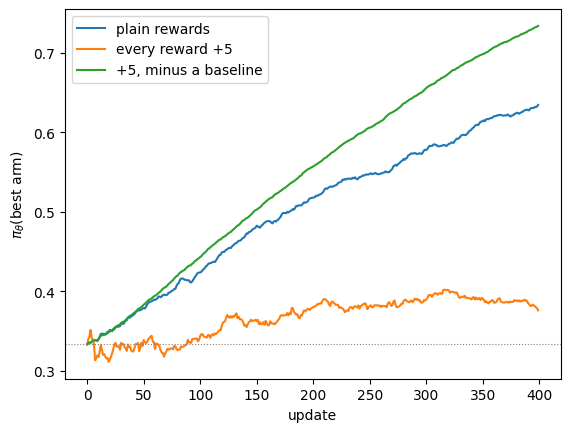

,s.d. of one-sample gradient
plain rewards,0.429509
every reward +5,1.303992
"+5, minus a baseline",0.155839


In [7]:
def reinforce(steps=400, eta=0.1, use_baseline=True, offset=0.0,
              noise=0.3, seed=SEED):
    """One REINFORCE run on the three-armed bandit.

    Rewards are random: arm a pays arm_rewards[a] + offset plus Gaussian noise.
    `offset` adds the same constant to every arm, which leaves the best arm
    unchanged but inflates every weight in the estimator.
    """
    generator = np.random.default_rng(seed)
    theta = np.zeros(3)
    running_mean = offset
    trace = np.empty(steps)
    grads = np.empty(steps)
    for step in range(steps):
        pi = softmax(theta)
        trace[step] = pi[1]                      # arm 2 is the best arm
        action = generator.choice(3, p=pi)
        reward = arm_rewards[action] + offset + generator.normal(0.0, noise)
        running_mean += (reward - running_mean) * 0.05
        weight = reward - running_mean if use_baseline else reward
        score = -pi.copy()
        score[action] += 1.0
        grads[step] = weight * score[1]
        theta = theta + eta * weight * score
    return trace, grads


settings = {
    "plain rewards":            dict(use_baseline=False, offset=0.0),
    "every reward +5":          dict(use_baseline=False, offset=5.0),
    "+5, minus a baseline":     dict(use_baseline=True,  offset=5.0),
}

curves, spreads = {}, {}
for label, kwargs in settings.items():
    runs = [reinforce(seed=SEED + k, **kwargs) for k in range(200)]
    curves[label] = np.mean([trace for trace, _ in runs], axis=0)
    spreads[label] = np.std(np.concatenate([g for _, g in runs]))

for label, curve in curves.items():
    plt.plot(curve, label=label)
plt.axhline(1/3, linestyle=":", linewidth=0.8, color="grey")
plt.xlabel("update")
plt.ylabel(r"$\pi_\theta$(best arm)")
plt.legend()
plt.show()

pd.Series(spreads, name="s.d. of one-sample gradient").to_frame()

The three runs are the *same* bandit. Adding a constant to every arm does not
change which arm is best, yet it stalls learning: every weight is now large and
positive, so each update mostly reports **which arm was drawn** rather than
**how good it was**. Subtracting the running mean reward removes that shared
offset and restores the first run.

This is why a baseline is standard practice. It leaves the expectation alone --
you verified that in the table above -- and only changes the variance.

## 5. Exact backups against fitted backups

Everything above assumed we could write down $P^\pi$ and hold one number per
state. Neither survives contact with a real problem: the states are too many to
enumerate, and the transitions are never handed to us. What survives is the
Bellman equation used as a *regression target*.

Replace the table $V(s)$ with a parametric $V_w(s)=\phi(s)^\top w$ and repeat:

$$w \leftarrow \arg\min_{w}\ \sum_{(s,r,s')}\Bigl(\phi(s)^\top w-\bigl[r+\gamma\,\phi(s')^\top w_{\text{old}}\bigr]\Bigr)^2 .$$

The bracket is the target. It is held fixed while $w$ is fitted, which is why
implementations speak of a *frozen* or *target* network. Two things are now
approximate that were not: the features may be unable to represent $V^\pi$, and
the transitions are sampled rather than known. This section separates the two.

In [8]:
# Deliberately deficient features: two numbers to describe three states, so the
# exact V^pi is outside the class we can represent.
FEATURES = np.array([[1.0, 0.0],
                     [1.0, 1.0],
                     [0.0, 1.0]])

pi_eval = softmax_rows(theta)
V_exact, _, _, _ = evaluate(pi_eval)
P_pi = np.einsum("sa,sat->st", pi_eval, P)
r_pi = np.einsum("sa,sa->s", pi_eval, R)

def fitted_evaluation(features, weighting, sweeps=200):
    # Least squares against the bootstrapped target, re-fitted each sweep.
    weights = np.zeros(features.shape[1])
    scale = np.diag(weighting)
    history = []
    for _ in range(sweeps):
        target = r_pi + GAMMA * P_pi @ (features @ weights)
        weights = np.linalg.solve(features.T @ scale @ features,
                                  features.T @ scale @ target)
        history.append(features @ weights)
    return weights, np.array(history)

# Weight states by how often the policy visits them: the stationary distribution
# of P^pi is the distribution the data would actually be drawn from.
eigenvalues, eigenvectors = np.linalg.eig(P_pi.T)
stationary = np.real(eigenvectors[:, np.argmin(np.abs(eigenvalues - 1))])
stationary = stationary / stationary.sum()

weights_fitted, sweeps = fitted_evaluation(FEATURES, stationary)
V_fitted = FEATURES @ weights_fitted

# The best any two-feature approximation could do, if we knew V^pi and fitted it
# directly rather than through the Bellman recursion.
scale = np.diag(stationary)
best_weights = np.linalg.solve(FEATURES.T @ scale @ FEATURES, FEATURES.T @ scale @ V_exact)
V_projection = FEATURES @ best_weights

pd.DataFrame({"exact V": V_exact,
              "fitted backups": V_fitted,
              "best 2-feature fit": V_projection,
              "visit frequency": stationary}).round(4)

,exact V,fitted backups,best 2-feature fit,visit frequency
0,2.8291,0.8667,1.6122,0.3032
1,2.9656,1.9157,4.1930,0.3006
2,3.5124,1.0490,2.5809,0.3962


best the features allow : 1.1161
what fitted backups got : 1.9756
inflation factor        : 1.77x
the bound 1/sqrt(1-gamma^2) = 2.29x


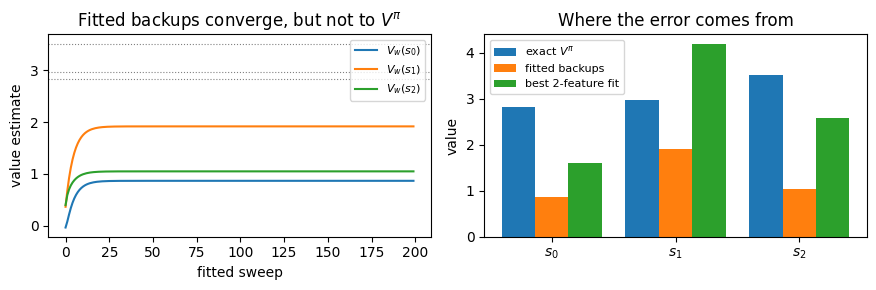

In [9]:
fig, (left, right) = plt.subplots(1, 2, figsize=(9, 3))
left.plot(sweeps[:, 0], label="$V_w(s_0)$")
left.plot(sweeps[:, 1], label="$V_w(s_1)$")
left.plot(sweeps[:, 2], label="$V_w(s_2)$")
for value in V_exact:
    left.axhline(value, color="gray", linewidth=0.8, linestyle=":")
left.set_xlabel("fitted sweep"); left.set_ylabel("value estimate")
left.set_title("Fitted backups converge, but not to $V^\\pi$"); left.legend(fontsize=8)

states = np.arange(3); width = 0.27
right.bar(states - width, V_exact, width, label="exact $V^\\pi$")
right.bar(states, V_fitted, width, label="fitted backups")
right.bar(states + width, V_projection, width, label="best 2-feature fit")
right.set_xticks(states); right.set_xticklabels(["$s_0$", "$s_1$", "$s_2$"])
right.set_ylabel("value"); right.legend(fontsize=8); right.set_title("Where the error comes from")
fig.tight_layout()

approximation = np.sqrt(stationary @ (V_projection - V_exact) ** 2)
achieved = np.sqrt(stationary @ (V_fitted - V_exact) ** 2)
print(f"best the features allow : {approximation:.4f}")
print(f"what fitted backups got : {achieved:.4f}")
print(f"inflation factor        : {achieved/approximation:.2f}x")
print(f"the bound 1/sqrt(1-gamma^2) = {1/np.sqrt(1-GAMMA**2):.2f}x")

Two separate things went wrong, and it is worth keeping them apart.

The **approximation error** is the gap between $V^\pi$ and the closest function
the features can express. No algorithm can beat it; it is a property of the
feature choice.

The **bootstrapping penalty** is the extra gap on top. Fitted evaluation does
not fit $V^\pi$ — it fits a target built from its own previous estimate, so its
error is fed back into the next target. The classical bound says the result can
be worse than the best possible fit by a factor of $1/\sqrt{1-\gamma^2}$, and
the printed ratio sits under it. Discounting closer to one makes both the bound
and the observed inflation worse.

Now the second approximation: the transitions are not given, only sampled.

 transitions     error
          50    1.5560
         200    2.1755
       1,000    1.8061
       5,000    1.9749
      20,000    1.9838

The curve settles onto the red line: with enough transitions, not knowing
P^pi costs nothing. It does not approach from above -- a small sample is noisy
and can land nearer the truth by luck -- but it converges there.

The gap between the red and grey lines is the one that does NOT shrink with
more data. It is the price of bootstrapping, and it is the error deep
reinforcement learning spends most of its effort on.


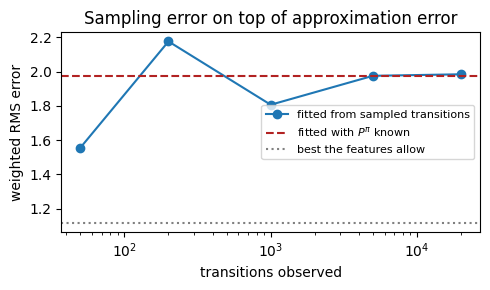

In [10]:
def sample_transitions(count, generator):
    # Roll out under pi and keep (s, r, s') triples, which is all a learner sees.
    states, rewards, next_states = [], [], []
    state = int(generator.choice(3, p=MU))
    for _ in range(count):
        action = int(generator.choice(2, p=pi_eval[state]))
        successor = int(generator.choice(3, p=P[state, action]))
        states.append(state); rewards.append(R[state, action]); next_states.append(successor)
        state = successor
    return np.array(states), np.array(rewards), np.array(next_states)

def fitted_evaluation_sampled(count, generator, sweeps=200):
    states, rewards, next_states = sample_transitions(count, generator)
    design, successor_design = FEATURES[states], FEATURES[next_states]
    weights = np.zeros(FEATURES.shape[1])
    for _ in range(sweeps):
        target = rewards + GAMMA * successor_design @ weights
        weights = np.linalg.lstsq(design, target, rcond=None)[0]
    return FEATURES @ weights

generator = np.random.default_rng(SEED + 3)
counts = [50, 200, 1000, 5000, 20000]
errors = [np.sqrt(stationary @ (fitted_evaluation_sampled(n, generator) - V_exact) ** 2)
          for n in counts]

fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(counts, errors, "o-", label="fitted from sampled transitions")
ax.axhline(achieved, color="firebrick", linestyle="--", label="fitted with $P^\\pi$ known")
ax.axhline(approximation, color="gray", linestyle=":", label="best the features allow")
ax.set_xscale("log"); ax.set_xlabel("transitions observed"); ax.set_ylabel("weighted RMS error")
ax.legend(fontsize=8); ax.set_title("Sampling error on top of approximation error")
fig.tight_layout()

print(f"{'transitions':>12}{'error':>10}")
for n, e in zip(counts, errors):
    print(f"{n:>12,}{e:>10.4f}")
print()
print("The curve settles onto the red line: with enough transitions, not knowing")
print("P^pi costs nothing. It does not approach from above -- a small sample is noisy")
print("and can land nearer the truth by luck -- but it converges there.")
print()
print("The gap between the red and grey lines is the one that does NOT shrink with")
print("more data. It is the price of bootstrapping, and it is the error deep")
print("reinforcement learning spends most of its effort on.")

## Try It

1. Change $\gamma$ in section 2. How many backups does the iteration need
   before it agrees with the linear solve to six decimals, and how does that
   number track $1/(1-\gamma)$?
2. In section 3, push one row of `theta` towards a deterministic policy. What
   happens to the advantages, and why does $\sum_a\pi A=0$ still hold?
3. Raise `offset` from 5 to 100 in the last experiment. How large does the
   step size have to become before the un-baselined run learns at all?
4. Raise `noise` instead, holding `offset` at zero. The baseline removes the
   shared offset --- which part of the variance does it leave behind?
5. Replace the running mean with the exact $b=J(\theta)$, recomputed each step
   from the current $\pi_\theta$. Does it beat the running mean, and why might
   one still prefer the running mean in practice?6. In section 5, replace `FEATURES` with the identity matrix, so the features
   can represent any value function. Confirm that fitted backups then recover
   $V^\pi$ exactly, and say which of the two error terms disappeared.
7. Raise $\gamma$ from 0.9 to 0.99 in section 5. Track the inflation factor
   against $1/\sqrt{1-\gamma^2}$.
8. In `fitted_evaluation`, stop freezing the target: substitute the current
   weights into the bracket and solve the resulting fixed point directly. What
   does the iteration do, and what does that suggest about target networks?
